In [3]:
import numpy as np
import pandas as pd


In [4]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: d:\Projects\ClassicalML\D13-end_to_end_Project


In [5]:
df = pd.read_csv('./placement.csv')

In [6]:
df.head()

,Unnamed:,0,cgpa,iq,placement
0,0,0,6.8,123.0,1
1,1,1,5.9,106.0,0
2,2,2,5.3,121.0,0
3,3,3,7.4,132.0,1
4,4,4,5.8,142.0,0


In [7]:
df.shape

(201, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Unnamed:   201 non-null    int64  
 1   0          201 non-null    int64  
 2   cgpa       201 non-null    float64
 3   iq         201 non-null    float64
 4   placement  201 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 8.0 KB


In [9]:
# Steps

#0. Preprocess + EDA + Feature Selection
#1. Extract input and output columns
#2. Scale the values
#3. Train Test Split
#4. Train the model
#5. Evaluate the model/model selection
#6. Deploy the model

In [10]:
# preprocess
df = df.iloc[:,2:]  # take all the rows and columns from index 2 to end

In [11]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [12]:
# EDA
import matplotlib.pyplot as plt

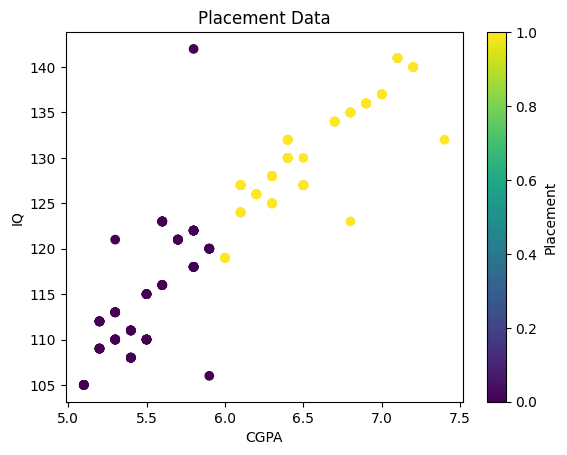

In [13]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Placement Data')
plt.colorbar(label='Placement')
plt.show()

In [14]:
# Extract input and output columns
x = df.iloc[:,0:2] # all rows, columns from index 0 to 1 (cgpa and iq)
y = df.iloc[:,-1] # all rows, last column (placement)


In [15]:
x.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [16]:
x.shape

(201, 2)

In [17]:
y.head()

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64

In [18]:
y.shape

(201,)

In [19]:
# Test Train Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1)

In [20]:
x_train.shape

(180, 2)

In [21]:
# sclale the values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [22]:
x_train = scaler.fit_transform(x_train)

In [23]:
x_train

array([[-0.1937402 , -0.26211361],
       [ 0.44613569,  0.51772853],
       [ 0.44613569,  0.51772853],
       [ 0.44613569,  0.51772853],
       [ 1.24598056,  1.20009041],
       [-0.35370917, -0.06715307],
       [-0.35370917, -0.45707414],
       [ 1.08601158,  1.10261014],
       [ 1.72588748,  1.78497201],
       [-1.15355404, -1.23691629],
       [ 0.44613569,  0.22528773],
       [-1.31352301, -1.04195575],
       [ 0.60610466,  0.71268907],
       [ 1.24598056,  1.20009041],
       [ 1.72588748,  1.78497201],
       [-0.99358507, -1.43187682],
       [ 0.12619775,  0.12780746],
       [-0.99358507, -1.43187682],
       [-1.47349198, -1.72431762],
       [-0.99358507, -1.13943602],
       [-0.99358507, -1.43187682],
       [ 0.12619775,  0.42024827],
       [-1.15355404, -0.94447548],
       [ 0.60610466,  0.9076496 ],
       [-0.03377123, -0.35959388],
       [ 0.44613569,  0.51772853],
       [-0.1937402 , -0.26211361],
       [-1.47349198, -1.72431762],
       [ 1.40594953,

In [24]:
x_test = scaler.transform(x_test)

In [25]:
# We will implement logistic regresion classifier
from sklearn.linear_model import LogisticRegression # its a class

In [26]:
clf = LogisticRegression()

In [27]:
# model training
clf.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
# model evaluation
y_pred = clf.predict(x_test)

In [29]:
y_test

78     0
152    0
38     0
161    1
24     0
194    0
140    0
33     1
108    0
31     1
160    0
188    0
155    1
48     0
27     1
18     0
109    1
184    0
9      1
165    1
41     1
Name: placement, dtype: int64

In [30]:
from sklearn.metrics import accuracy_score

In [31]:
accuracy_score(y_test, y_pred)

1.0

## How to plot the decision boundary of the logistic regression

In [32]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

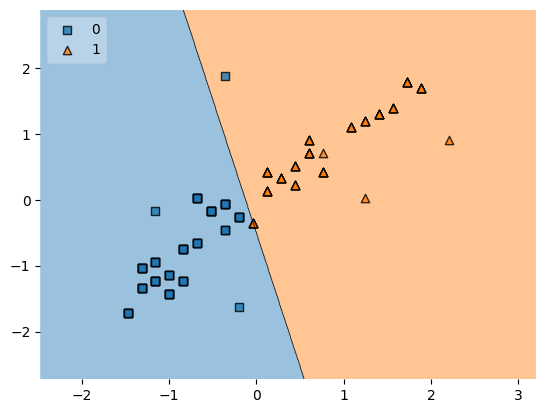

In [33]:
plot_decision_regions(x_train,y_train.values, clf=clf, legend=2)